In [307]:
# Cell 1: Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from dataclasses import dataclass
import heapq
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

#CONSTANTS
MAX_WALK = 12 # Maximum walking amount of 12 minutes
PRICE_WEIGHT = 2.0 # Every dollar for the parking lot price = 2 minutes

In [308]:
# Cell 2: Expanded Graph Definition

TRAVEL_TIMES = {
    ('S', 'A'): 4,
    ('S', 'B'): 5,
    ('A', 'C'): 3,
    ('A', 'D'): 6,
    ('B', 'D'): 2,
    ('B', 'E'): 4,
    ('C', 'F'): 5,
    ('D', 'F'): 3,
    ('D', 'G'): 2,
    ('E', 'G'): 4,
    ('F', 'H'): 2,
    ('G', 'H'): 3,
    ('H', 'D_end'): 2
}

ADJ = defaultdict(list)
for (u, v), cost in TRAVEL_TIMES.items():
    ADJ[u].append(v)

START = 'S'
DESTINATION = 'D_end'

ORIGINAL_TRAVEL_TIMES = dict(TRAVEL_TIMES)

In [309]:
# Cell 3: Expanded Parking Lot Definition

LOTS = {
    'C': {'price': 6, 'walk_min': 12, 'capacity': 12, 'occupied': 8},
    'E': {'price': 4, 'walk_min': 18, 'capacity': 10, 'occupied': 6},
    'F': {'price': 7, 'walk_min': 8,  'capacity': 15, 'occupied': 14},
    'G': {'price': 5, 'walk_min': 10, 'capacity': 8,  'occupied': 3},
    'H': {'price': 9, 'walk_min': 4,  'capacity': 6,  'occupied': 5}
}

MAX_WALK = 12
PRICE_WEIGHT = 1

print(LOTS)

ORIGINAL_LOTS = {k: v.copy() for k, v in LOTS.items()}

{'C': {'price': 6, 'walk_min': 12, 'capacity': 12, 'occupied': 8}, 'E': {'price': 4, 'walk_min': 18, 'capacity': 10, 'occupied': 6}, 'F': {'price': 7, 'walk_min': 8, 'capacity': 15, 'occupied': 14}, 'G': {'price': 5, 'walk_min': 10, 'capacity': 8, 'occupied': 3}, 'H': {'price': 9, 'walk_min': 4, 'capacity': 6, 'occupied': 5}}


In [310]:
# Cell 4: Functions for RL environment

def lot_valid(lot):
    return (
        LOTS[lot]['occupied'] < LOTS[lot]['capacity']
        and LOTS[lot]['walk_min'] <= MAX_WALK
    )

def total_cost(travel_cost, lot):
    return travel_cost + LOTS[lot]['price'] * PRICE_WEIGHT + LOTS[lot]['walk_min']

for lot in LOTS:
    print(lot, "valid =", lot_valid(lot))

C valid = True
E valid = False
F valid = True
G valid = True
H valid = True


In [311]:
# Cell 5: Shortest path calculation 

def shortest_path_cost(start, goal):
    pq = [(0, start)]
    visited = set()

    while pq:
        cost, node = heapq.heappop(pq)

        if node == goal:
            return cost

        if node in visited:
            continue
        visited.add(node)

        for neighbor in ADJ[node]:
            edge_cost = TRAVEL_TIMES[(node, neighbor)]
            heapq.heappush(pq, (cost + edge_cost, neighbor))

    return float('inf')

In [312]:
# Cell 6: Baseline evaluation of parking lots

def baseline_best_lot():
    best_lot = None
    best_score = float('inf')

    for lot in LOTS:
        if lot_valid(lot):
            drive_cost = shortest_path_cost(START, lot)
            score = total_cost(drive_cost, lot)

            print(f"Lot {lot}: drive={drive_cost}, total score={score}")

            if score < best_score:
                best_score = score
                best_lot = lot

    return best_lot, best_score

result = baseline_best_lot()
print("\nBest lot:", result[0])
print("Best score:", result[1])

Lot C: drive=7, total score=25
Lot F: drive=10, total score=25
Lot G: drive=9, total score=24
Lot H: drive=12, total score=25

Best lot: G
Best score: 24


In [313]:
# Cell 7: Q-learning setup

states = list(set([u for u, v in TRAVEL_TIMES] + [v for u, v in TRAVEL_TIMES]))
actions = {state: ADJ[state] for state in ADJ}

Q = {
    state: {action: 0.0 for action in actions.get(state, [])}
    for state in states
}

alpha = 0.1
gamma = 1.0
epsilon = 0.2
episodes = 500

In [314]:
# Cell 8: Reward function for RL

def get_reward(current, next_node):
    travel_penalty = -TRAVEL_TIMES[(current, next_node)]

    if next_node in LOTS:
        if lot_valid(next_node):
            success_reward = 120
            cost_penalty = PRICE_WEIGHT * LOTS[next_node]['price'] + LOTS[next_node]['walk_min']
            return success_reward + travel_penalty - cost_penalty
        else:
            return -120

    return travel_penalty

In [315]:
# Cell 9: Q-learning Static Training Loop

def train_q_learning_static(episodes=750):
    global Q, reward_history

    Q = {
        state: {action: 0.0 for action in actions.get(state, [])}
        for state in states
    }

    reward_history = []

    local_epsilon = 1.0
    min_epsilon = 0.05
    epsilon_decay = 0.995

    for episode in range(episodes):
        state = START
        total_episode_reward = 0

        while state in actions:
            if random.random() < local_epsilon:
                action = random.choice(actions[state])
            else:
                action = max(Q[state], key=Q[state].get)

            reward = get_reward(state, action)
            total_episode_reward += reward
            next_state = action

            if next_state in actions and len(Q[next_state]) > 0:
                max_future_q = max(Q[next_state].values())
            else:
                max_future_q = 0

            Q[state][action] += alpha * (
                reward + gamma * max_future_q - Q[state][action]
            )

            if next_state in LOTS and lot_valid(next_state):
                break

            state = next_state

        reward_history.append(total_episode_reward)
        local_epsilon = max(min_epsilon, local_epsilon * epsilon_decay)

In [316]:
# Cell 10: Retrain model and print learned Q-values

train_q_learning_static()

# print learned Q-values
print("Learned Q-table:")
for state in Q:
    print(state, Q[state])

Learned Q-table:
C {'F': 0.0}
H {'D_end': 0.0}
E {'G': 99.15695163322853}
S {'A': 94.9999928384335, 'B': 95.99999999999983}
F {'H': 0.0}
A {'C': 98.99999912437762, 'D': 95.7417794173127}
B {'D': 100.99999999999989, 'E': -26.435047701816266}
G {'H': 0.0}
D_end {}
D {'F': 101.41590547650372, 'G': 102.99999999999994}


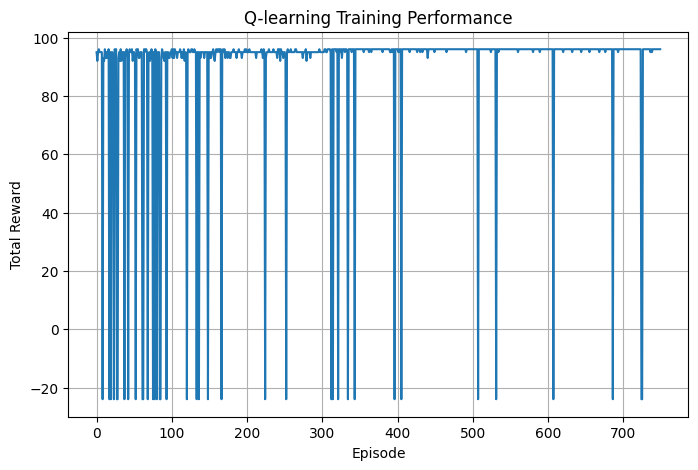

In [317]:
# Cell 11: Plot training performance

plt.figure(figsize=(8,5))
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-learning Training Performance")
plt.grid(True)
plt.show()

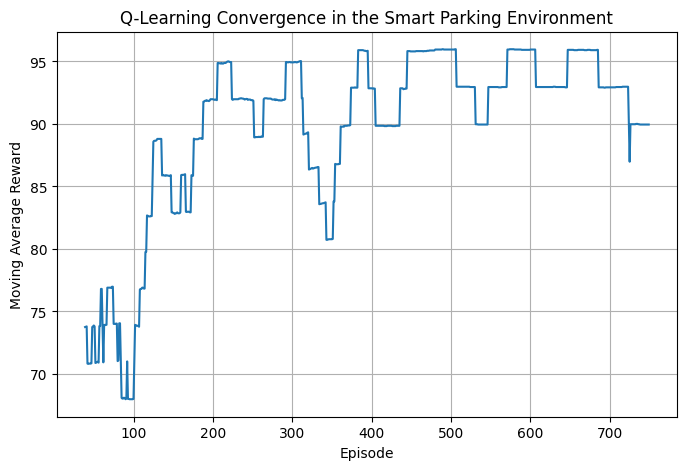

In [318]:
# Cell 12: Plot smoothed rewards

window = 40
smoothed_rewards = pd.Series(reward_history).rolling(window).mean()

plt.figure(figsize=(8,5))
plt.plot(smoothed_rewards)
plt.xlabel("Episode")
plt.ylabel("Moving Average Reward")
plt.title("Q-Learning Convergence in the Smart Parking Environment")
plt.grid(True)
plt.show()

In [319]:
# Cell 13: Extract best route from learned Q-values

def get_best_route():
    route = [START]
    state = START

    while state in Q and len(Q[state]) > 0:
        next_state = max(Q[state], key=Q[state].get)
        route.append(next_state)

        if next_state in LOTS and lot_valid(next_state):
            break

        state = next_state

    return route

best_route = get_best_route()
print("Learned best route:", " -> ".join(best_route))

Learned best route: S -> B -> D -> G


In [320]:
# Cell 14: Dynamic environment updates

def update_dynamic_traffic():
    for edge in ORIGINAL_TRAVEL_TIMES:
        base_time = ORIGINAL_TRAVEL_TIMES[edge]
        fluctuation = random.randint(-1, 2)
        TRAVEL_TIMES[edge] = max(1, base_time + fluctuation)


def update_dynamic_occupancy():
    for lot in LOTS:
        current = LOTS[lot]['occupied']
        capacity = LOTS[lot]['capacity']

        LOTS[lot]['occupied'] = min(
            capacity,
            max(0, current + random.randint(-1, 1))
        )


def update_dynamic_prices():
    for lot in LOTS:
        occupancy_ratio = (
            LOTS[lot]['occupied'] / LOTS[lot]['capacity']
        )

        LOTS[lot]['price'] = round(
            5 + 10 * occupancy_ratio,
            1
        )

In [321]:
# Cell 15: Q-learning Training Loop

def train_q_learning_dynamic(episodes=750):
    global Q, reward_history

    Q = {
        state: {action: 0.0 for action in actions.get(state, [])}
        for state in states
    }

    reward_history = []

    local_epsilon = 1.0
    min_epsilon = 0.05
    epsilon_decay = 0.995

    for episode in range(episodes):
        if episode % 75 == 0:
            update_dynamic_traffic()
            update_dynamic_occupancy()
            update_dynamic_prices()

        state = START
        total_episode_reward = 0

        while state in actions:
            if random.random() < local_epsilon:
                action = random.choice(actions[state])
            else:
                action = max(Q[state], key=Q[state].get)

            reward = get_reward(state, action)
            total_episode_reward += reward
            next_state = action

            if next_state in actions and len(Q[next_state]) > 0:
                max_future_q = max(Q[next_state].values())
            else:
                max_future_q = 0

            Q[state][action] += alpha * (
                reward + gamma * max_future_q - Q[state][action]
            )

            if next_state in LOTS and lot_valid(next_state):
                break

            state = next_state

        reward_history.append(total_episode_reward)

        local_epsilon = max(min_epsilon, local_epsilon * epsilon_decay)

In [322]:
# Cell 16: Retrain model and print learned Q-values

train_q_learning_dynamic()

# print learned Q-values
print("Learned Q-table:")
for state in Q:
    print(state, Q[state])

Learned Q-table:
C {'F': 0.0}
H {'D_end': 0.0}
E {'G': 92.54621170457851}
S {'A': 88.95984868891786, 'B': 89.80041894151022}
F {'H': 0.0}
A {'C': 92.68636087125039, 'D': 90.03232685003977}
B {'D': 95.80039413339644, 'E': -34.14816246500099}
G {'H': 0.0}
D_end {}
D {'F': 93.51055020020193, 'G': 97.80011034664011}


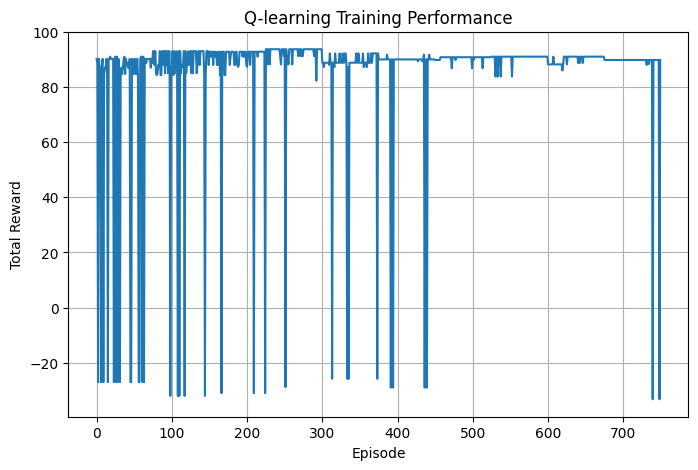

In [323]:
# Cell 17: Plot training performance

plt.figure(figsize=(8,5))
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-learning Training Performance")
plt.grid(True)
plt.show()

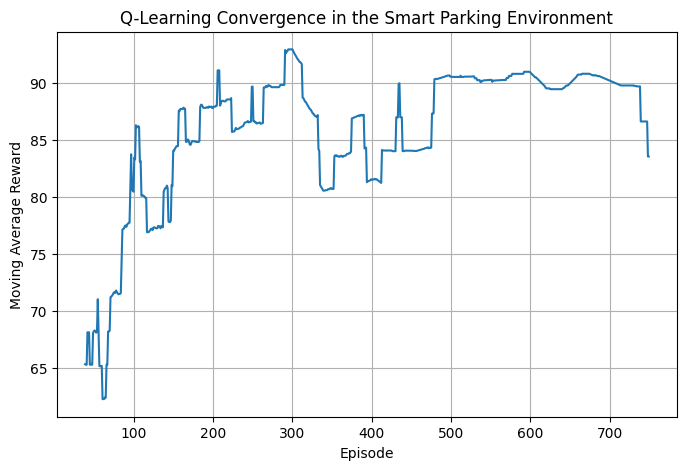

In [324]:
# Cell 18: Plot smoothed rewards

window = 40
smoothed_rewards = pd.Series(reward_history).rolling(window).mean()

plt.figure(figsize=(8,5))
plt.plot(smoothed_rewards)
plt.xlabel("Episode")
plt.ylabel("Moving Average Reward")
plt.title("Q-Learning Convergence in the Smart Parking Environment")
plt.grid(True)
plt.show()

In [325]:
# Cell 19: Extract best route from learned Q-values

def get_best_route():
    route = [START]
    state = START

    while state in Q and len(Q[state]) > 0:
        next_state = max(Q[state], key=Q[state].get)
        route.append(next_state)

        if next_state in LOTS and lot_valid(next_state):
            break

        state = next_state

    return route

best_route = get_best_route()
print("Learned best route:", " -> ".join(best_route))

Learned best route: S -> B -> D -> G


In [326]:
# Cell 20: Main function to run baseline and RL

def run_baseline():
    lot, score = baseline_best_lot()
    return {
        "method": "Baseline",
        "best_lot": lot,
        "score": score
    }

In [327]:
# Cell 21: Main function to run Q-learning results

def run_q_learning():
    route = get_best_route()
    chosen_lot = route[-1]

    if chosen_lot in LOTS:
        score = total_cost(
            shortest_path_cost(START, chosen_lot),
            chosen_lot
        )
    else:
        score = None

    return {
        "method": "Q-Learning",
        "route": route,
        "best_lot": chosen_lot,
        "score": score
    }

In [328]:
# Cell 22: Run scenario tests and display results

def run_scenario_test():
    results = []

    scenarios = [
        ("Normal", None),
        ("Traffic Spike", "traffic"),
        ("C Full", "full"),
        ("E Expensive", "price")
    ]

    for scenario_name, scenario_type in scenarios:

        # Reset to TRUE originals (not whatever state training left them in)
        TRAVEL_TIMES.update(ORIGINAL_TRAVEL_TIMES)
        for lot in LOTS:
            LOTS[lot].update(ORIGINAL_LOTS[lot])

        # Apply the scenario modification
        if scenario_type == "traffic":
            TRAVEL_TIMES[('S', 'A')] = 8
        elif scenario_type == "full":
            LOTS['C']['occupied'] = LOTS['C']['capacity']
        elif scenario_type == "price":
            LOTS['E']['price'] = 20

        # Snapshot scenario state so we can restore it after training
        scenario_travel = dict(TRAVEL_TIMES)
        scenario_lots = {k: v.copy() for k, v in LOTS.items()}

        # Baseline runs under scenario conditions
        baseline_result = run_baseline()

        # Training may mutate TRAVEL_TIMES via update_dynamic_traffic
        train_q_learning_dynamic()

        # Restore scenario conditions so Q-learning is evaluated
        # under the same environment as the baseline
        TRAVEL_TIMES.update(scenario_travel)
        for lot in LOTS:
            LOTS[lot].update(scenario_lots[lot])

        q_result = run_q_learning()

        results.append({
            "Scenario": scenario_name,
            "Baseline Lot": baseline_result["best_lot"],
            "Baseline Score": baseline_result["score"],
            "Q Lot": q_result["best_lot"],
            "Q Score": q_result["score"]
        })

    return pd.DataFrame(results)

In [329]:
# Cell 23: Run scenario tests and display results

scenario_results = run_scenario_test()
scenario_results

Lot C: drive=7, total score=25
Lot F: drive=10, total score=25
Lot G: drive=9, total score=24
Lot H: drive=12, total score=25
Lot C: drive=11, total score=29
Lot F: drive=10, total score=25
Lot G: drive=9, total score=24
Lot H: drive=12, total score=25
Lot F: drive=10, total score=25
Lot G: drive=9, total score=24
Lot H: drive=12, total score=25
Lot C: drive=7, total score=25
Lot F: drive=10, total score=25
Lot G: drive=9, total score=24
Lot H: drive=12, total score=25


,Scenario,Baseline Lot,Baseline Score,Q Lot,Q Score
0,Normal,G,24,G,24
1,Traffic Spike,G,24,C,29
2,C Full,G,24,F,25
3,E Expensive,G,24,G,24


In [330]:
# Cell 24: DQN Setup with PyTorch

NODES_LIST = ['S', 'A', 'B', 'C', 'D', 'D_end', 'E', 'F', 'G', 'H']
NODE_TO_IDX = {n: i for i, n in enumerate(NODES_LIST)}
N_NODES     = len(NODES_LIST)

def encode_state(node):
    s = torch.zeros(N_NODES)
    s[NODE_TO_IDX[node]] = 1.0
    return s

def valid_action_indices(node):
    return [NODE_TO_IDX[nb] for nb in ADJ.get(node, [])]

class DQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_NODES, 64),
            nn.ReLU(),
            nn.Linear(64, N_NODES)
        )
    def forward(self, x):
        return self.net(x)

In [331]:
# Cell 25: DQN Training

def train_dqn(episodes=1000, lr=0.005, gamma=1.0,
              eps_start=1.0, eps_end=0.05, eps_decay=0.995):

    dqn       = DQN()
    optimizer = optim.Adam(dqn.parameters(), lr=lr)
    loss_fn   = nn.MSELoss()
    eps       = eps_start
    history   = []

    for ep in range(episodes):
        node   = START
        ep_rew = 0.0

        while node in actions:
            valid = valid_action_indices(node)
            if not valid:
                break

            s_vec = encode_state(node)

            # Epsilon-greedy action selection
            if random.random() < eps:
                action_idx = random.choice(valid)
            else:
                with torch.no_grad():
                    q_vals     = dqn(s_vec)
                    action_idx = max(valid, key=lambda i: q_vals[i].item())

            next_node = NODES_LIST[action_idx]
            reward    = get_reward(node, next_node)
            ep_rew   += reward
            done      = next_node in LOTS and lot_valid(next_node)

            # TD target
            if done:
                td_target = torch.tensor([reward], dtype=torch.float32)
            else:
                with torch.no_grad():
                    nv        = valid_action_indices(next_node)
                    next_q    = dqn(encode_state(next_node))
                    best_next = max(next_q[i].item() for i in nv) if nv else 0.0
                    td_target = torch.tensor([reward + gamma * best_next], dtype=torch.float32)

            # One gradient step
            q_pred = dqn(s_vec)[action_idx].unsqueeze(0)
            loss   = loss_fn(q_pred, td_target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if done:
                break
            node = next_node

        eps = max(eps_end, eps * eps_decay)
        history.append(ep_rew)

    return dqn, history

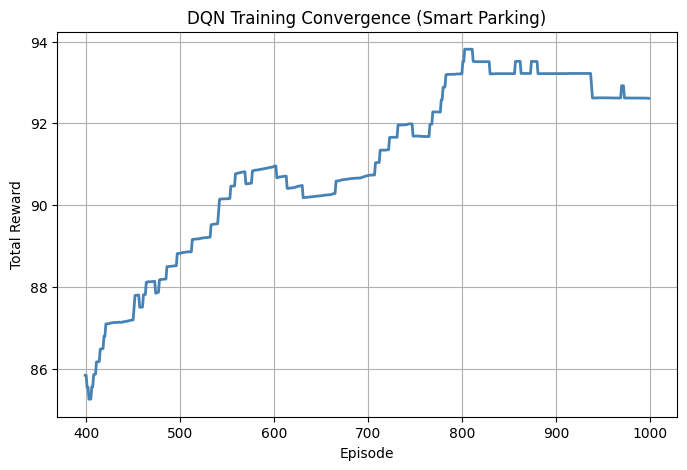

DQN best route: S -> B -> D -> G
  Lot: G  |  Drive: 9  |  Score: 24


In [ ]:
# Cell 26: Train DQN, Plot Convergence, Print Best Route

torch.manual_seed(42)
random.seed(42)

dqn_net, dqn_history = train_dqn(episodes=1000)

# Convergence plot
plt.figure(figsize=(8, 5))
plt.plot(pd.Series(dqn_history).rolling(400).mean(),
         color='steelblue', linewidth=2, label='400-ep moving average')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('DQN Training Convergence (Smart Parking)')
plt.grid(True)
plt.show()

# Greedy rollout
def get_dqn_best_route(net):
    route, node = [START], START
    while node in actions:
        valid = valid_action_indices(node)
        if not valid:
            break
        with torch.no_grad():
            q_vals    = net(encode_state(node))
            best_idx  = max(valid, key=lambda i: q_vals[i].item())
        next_node = NODES_LIST[best_idx]
        route.append(next_node)
        if next_node in LOTS and lot_valid(next_node):
            break
        node = next_node
    return route

dqn_route = get_dqn_best_route(dqn_net)
chosen    = dqn_route[-1]
drive     = shortest_path_cost(START, chosen)
score     = total_cost(drive, chosen)

print("DQN best route:", " -> ".join(dqn_route))
print(f"  Lot: {chosen}  |  Drive: {drive}  |  Score: {score}")

In [333]:
# Cell 27: Three-Way Scenario Comparison

def run_full_comparison():
    results   = []
    scenarios = [
        ("Normal",        None),
        ("Traffic Spike", "traffic"),
        ("C Full",        "full"),
        ("E Expensive",   "price"),
    ]

    for name, stype in scenarios:

        # Reset and apply scenario
        TRAVEL_TIMES.update(ORIGINAL_TRAVEL_TIMES)
        for lot in LOTS:
            LOTS[lot].update(ORIGINAL_LOTS[lot])

        if stype == "traffic":
            TRAVEL_TIMES[('S', 'A')] = 8
        elif stype == "full":
            LOTS['C']['occupied'] = LOTS['C']['capacity']
        elif stype == "price":
            LOTS['E']['price'] = 20

        snap_travel = dict(TRAVEL_TIMES)
        snap_lots   = {k: v.copy() for k, v in LOTS.items()}

        # Baseline
        baseline = run_baseline()

        # Tabular Q
        train_q_learning_dynamic()
        TRAVEL_TIMES.update(snap_travel)
        for lot in LOTS:
            LOTS[lot].update(snap_lots[lot])
        tabular = run_q_learning()

        # DQN
        TRAVEL_TIMES.update(snap_travel)
        for lot in LOTS:
            LOTS[lot].update(snap_lots[lot])
        torch.manual_seed(42)
        random.seed(42)
        dqn_trained, _ = train_dqn(episodes=500)
        TRAVEL_TIMES.update(snap_travel)
        for lot in LOTS:
            LOTS[lot].update(snap_lots[lot])

        dqn_route = get_dqn_best_route(dqn_trained)
        dqn_lot   = dqn_route[-1]
        dqn_score = (total_cost(shortest_path_cost(START, dqn_lot), dqn_lot)
                     if dqn_lot in LOTS else None)

        results.append({
            "Scenario":        name,
            "Baseline Lot":    baseline["best_lot"],
            "Baseline Score":  baseline["score"],
            "Tabular Q Lot":   tabular["best_lot"],
            "Tabular Q Score": tabular["score"],
            "DQN Lot":         dqn_lot,
            "DQN Score":       dqn_score,
        })

    return pd.DataFrame(results)

comparison_df = run_full_comparison()
comparison_df

Lot C: drive=7, total score=25
Lot F: drive=10, total score=25
Lot G: drive=9, total score=24
Lot H: drive=12, total score=25
Lot C: drive=11, total score=29
Lot F: drive=10, total score=25
Lot G: drive=9, total score=24
Lot H: drive=12, total score=25
Lot F: drive=10, total score=25
Lot G: drive=9, total score=24
Lot H: drive=12, total score=25
Lot C: drive=7, total score=25
Lot F: drive=10, total score=25
Lot G: drive=9, total score=24
Lot H: drive=12, total score=25


,Scenario,Baseline Lot,Baseline Score,Tabular Q Lot,Tabular Q Score,DQN Lot,DQN Score
0,Normal,G,24,C,25,G,24
1,Traffic Spike,G,24,C,29,G,24
2,C Full,G,24,G,24,G,24
3,E Expensive,G,24,G,24,G,24
